# **Cat Detector**



## **Description**  

In this this project we implement a system for detecting cat faces in images using the Haar Cascade classifier. We process individual images or a batch of images from a specified directory, annotating detected faces with bounding boxes and labels. The processed images are saved to an output folder, and the results can be visualized using Matplotlib.

## **Requirements**  

* **Libraries**: OpenCV, NumPy, Matplotlib, OS, Glob  
* **File Structure**:  
  - Input images stored in `images/`  
  - Haar Cascade model stored in `models/`  
  - Output images stored in `outputImages/`  


## **Outputs**  

### **Expected Outputs**  

1. **Images**:  
   - Input images annotated with detected cat faces.  
   - Visualizations of processed results, showing bounding boxes and labels for detected cats.  

### **Sample Outputs**  

The processed images, with annotations for detected cat faces, are saved in the `outputImages/` directory.  


## **Algorithm Details**  

1. **Load Image**  
    - The script reads images from the `images/` folder.  
    - Converts the image from BGR to RGB color space for visualization using Matplotlib.  


2. **Detect Cat Faces**  
    - Loads the model from the `models/` directory.  
    - Converts the image to grayscale and uses the `detectMultiScale` method to identify cat faces.  
    - Annotates each detected cat face with a bounding box and label (e.g., "Cat #1").  

3. **Save and Display Results**  
    - Saves the annotated images in the `outputImages/` directory.  
    - Displays the original and annotated images using Matplotlib.  



# Requirements

In [1]:
import cv2
import os
import matplotlib.pyplot as plt

# Loading Image

In [2]:
# Define the path to the image file using os.path.join for cross-platform compatibility
image_address = os.path.join("images", "image.webp")

# Define the path to the Haar Cascade model file using os.path.join for cross-platform compatibility
model = os.path.join("models", "haarcascade_frontalcatface_extended.xml")

# Read the input image from the specified path
image = cv2.imread(image_address)

# Convert the image from BGR to RGB format (as OpenCV uses BGR by default and Matplotlib uses RGB)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)



**Code Report**

This code snippet demonstrates the process of loading and preparing an image for further processing, such as object detection, in a cross-platform compatible way.

1. **Path Definition with Cross-Platform Compatibility:**
   The `os.path.join` method is used to define file paths for both the image and the Haar Cascade model. This ensures that the file paths are constructed correctly regardless of the operating system (Windows, macOS, Linux).

   * `image_address` points to an image file named `image.webp` inside the `images` directory.
   * `model` points to the Haar Cascade XML file `haarcascade_frontalcatface_extended.xml` inside the `models` directory.

2. **Image Reading:**
   The image located at the path specified by `image_address` is read into memory using OpenCV's `cv2.imread` function. OpenCV loads images in BGR color format by default.

3. **Color Space Conversion:**
   Since OpenCV uses BGR color format but many visualization libraries like Matplotlib expect RGB format, the code converts the image from BGR to RGB using `cv2.cvtColor`. This conversion ensures accurate color representation when displaying the image.


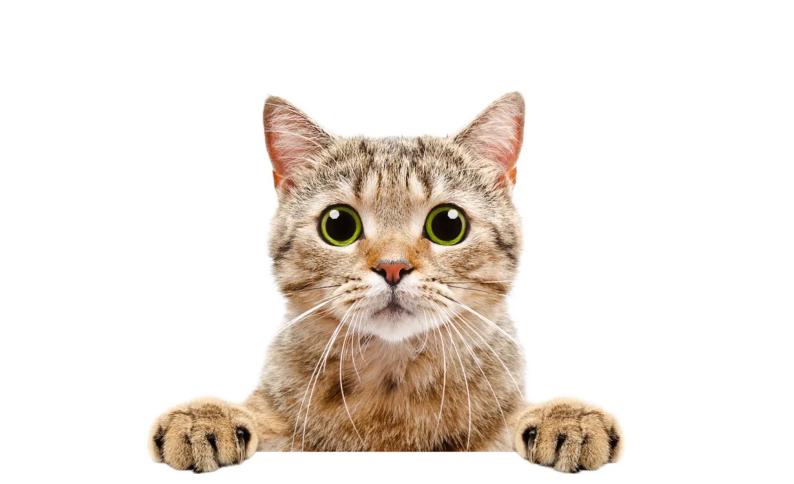

In [3]:
# Create a figure with specified size to display the image
plt.figure(figsize=(10, 8))

# Display the image using Matplotlib
plt.imshow(image)

# Turn off the axis for a cleaner look
plt.axis('off')

# Show the figure
plt.show()

# Detecting Cat

In [4]:
# Load the Haar Cascade model for cat face detection
detector = cv2.CascadeClassifier(model)

# Detect cat faces in the image using the loaded model
# scaleFactor: Parameter specifying how much the image size is reduced at each image scale
# minNeighbors: Parameter specifying how many neighbors each candidate rectangle should have to retain it
# minSize: Minimum possible object size. Objects smaller than this are ignored.
rects = detector.detectMultiScale(cv2.cvtColor(image, cv2.COLOR_RGB2GRAY), scaleFactor=1.02, minNeighbors=2, minSize=(180, 180))

# Iterate over the detected rectangles (bounding boxes for cat faces)
for (i, (x, y, w, h)) in enumerate(rects):
    # Draw a rectangle around the detected cat face
    # Annotate the image with the text 'Cat #N' above the rectangle
    cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 2)
    cv2.putText(image, f'Cat #{i+1}', (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2, cv2.LINE_AA)

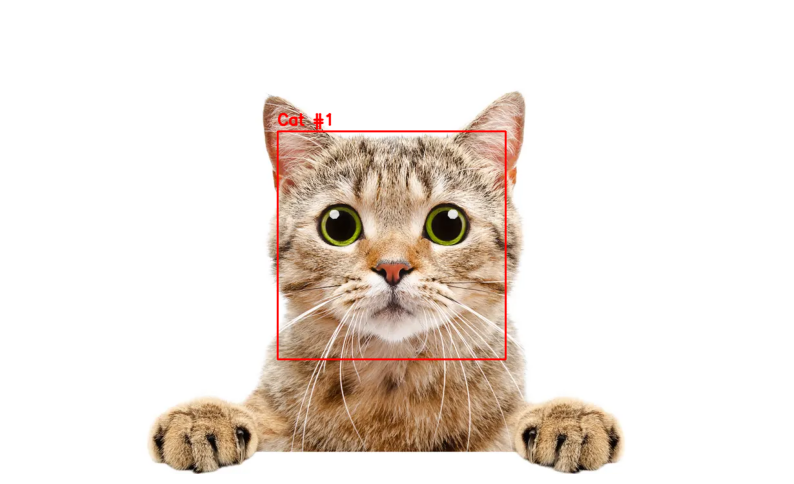

In [5]:
# Create a figure with specified size to display the image
plt.figure(figsize=(10, 8))

# Display the image with detected cat faces and annotations
plt.imshow(image)


# Turn off the axis for a cleaner look
plt.axis('off')

# Show the figure
plt.show()


In [6]:
def display_images_from_dict(images_dict, num_columns=3, size=5):
    titles = list(images_dict.keys())
    images = list(images_dict.values())
    num_rows = (len(images) + num_columns - 1) // num_columns 

    plt.figure(figsize=(size * num_columns, size * num_rows))

    for index, (title, image) in enumerate(zip(titles, images)):
        plt.subplot(num_rows, num_columns, index + 1)
        cmap = 'gray' if len(image.shape) == 2 else None
        plt.imshow(image, cmap=cmap)

        plt.title(title, fontsize=8)
        plt.axis('off')

    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    plt.tight_layout(pad=0.1)
    plt.show()


In [7]:
import numpy as np
import glob
def detectCat(image):
    detector = cv2.CascadeClassifier(model)
    imageCopy = np.copy(image)
    rects = detector.detectMultiScale(cv2.cvtColor(imageCopy, cv2.COLOR_RGB2GRAY), scaleFactor=1.02, minNeighbors=2, minSize=(180, 180))

    for (i, (x, y, w, h)) in enumerate(rects):
        cv2.rectangle(imageCopy, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(imageCopy, f'Cat #{i+1}', (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255, 0), 2, cv2.LINE_AA)
    return imageCopy

### 1. **Loading the Haar Cascade Model and Detecting Cat Faces**

* The Haar Cascade model for cat face detection is loaded using OpenCV's `CascadeClassifier`, with the path specified in the variable `model`.
* The input image is converted to grayscale since the detection algorithm operates on single-channel images.
* The `detectMultiScale` method is called on the grayscale image to detect cat faces. Parameters used include:

  * `scaleFactor=1.02`: This specifies how much the image size is reduced at each scale during detection, allowing for multi-scale detection of objects of varying sizes.
  * `minNeighbors=2`: Sets the minimum number of overlapping detections required to retain a candidate rectangle, helping to reduce false positives.
  * `minSize=(180, 180)`: Ignores detected objects smaller than this size, focusing the detection on larger cat faces.

### 2. **Annotating Detected Faces**

* For each detected cat face (returned as rectangles), a bounding box is drawn on the original image using `cv2.rectangle`.
* A label such as `'Cat #1'`, `'Cat #2'`, etc., is added above each bounding box using `cv2.putText` for clarity.

### 3. **Displaying the Annotated Image**

* The annotated image with detected cat faces is displayed using Matplotlib (`plt.imshow`) with a figure size of 10x8 inches.
* Axis ticks and labels are turned off for a cleaner visual presentation.

### 4. **Utility Function: `display_images_from_dict`**

* This function takes a dictionary of images with their titles as keys and displays them in a grid layout.
* The number of columns and the size of each image can be customized.
* Each image is shown with its title above it, and grayscale images are handled properly by setting the colormap.

### 5. **Function: `detectCat`**

* This reusable function accepts an image, copies it, and runs the cat face detector on the copy.
* It draws bounding boxes and labels on the copied image to avoid altering the original input.
* The function returns the annotated copy, making it suitable for batch processing or repeated use without modifying the original images.

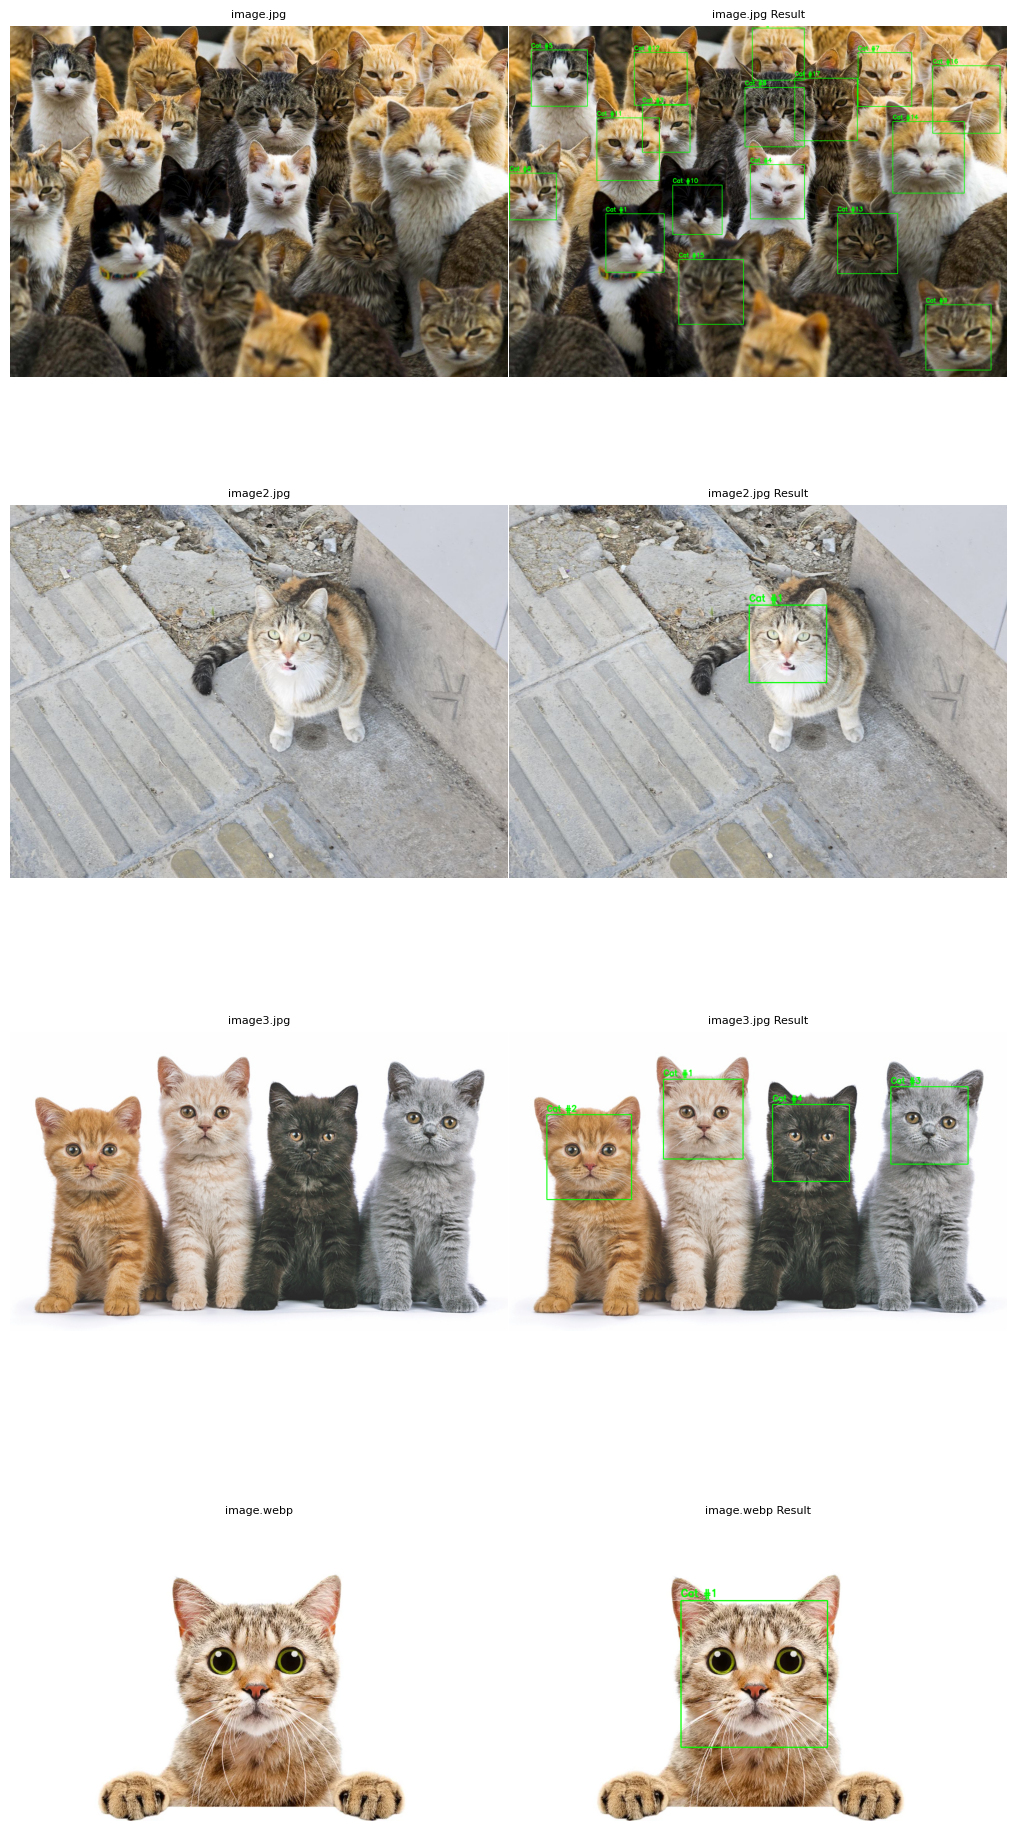

In [13]:
images_dict = {}
def apply_cat_detection_to_image(image_path, images_dict):
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    result = detectCat(image_rgb)
    filename = os.path.basename(image_path)
    output_path = os.path.join(OUTPUT_FOLDER, "detected_" + filename)
    result_bgr = cv2.cvtColor(result, cv2.COLOR_RGB2BGR)
    images_dict[filename] = image_rgb
    images_dict[filename + " Result"] = result
    cv2.imwrite(output_path, result_bgr)

OUTPUT_FOLDER = "outputImages"
if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)
image_files = glob.glob(os.path.join("images", "*.[jp][pn]g")) + glob.glob(os.path.join("images", "*.jpeg")) + glob.glob(os.path.join("images", "*.webp"))


for image_path in image_files:
    apply_cat_detection_to_image(image_path, images_dict)

display_images_from_dict(images_dict,2)

This code performs automated cat face detection on multiple images stored in a directory, saves the results, and displays the original and processed images side-by-side.

### 1. **Setup and Directory Preparation**

* The output folder path is defined as `"outputImages"`.
* If this folder does not already exist, it is created using `os.makedirs` to store the processed images with detected cat faces.

### 2. **Collecting Input Images**

* The code uses the `glob` module to search and collect image file paths from the `"images"` directory.
* It searches for images with the extensions `.jpg`, `.png`, `.jpeg`, and `.webp` by combining multiple glob patterns to ensure a wide range of common image formats are covered.

### 3. **Function: `apply_cat_detection_to_image`**

* This function accepts the path to a single image and a dictionary to store images for later display.
* Steps inside the function:

  * The image is read from disk in BGR format using OpenCV’s `cv2.imread`.
  * The image is converted from BGR to RGB to be compatible with the detection and display functions.
  * The `detectCat` function (previously defined) is called on the RGB image to detect cat faces and annotate the image with bounding boxes and labels.
  * The filename is extracted from the path to create a corresponding output filename prefixed with `"detected_"`.
  * The annotated image is converted back from RGB to BGR before saving, since OpenCV expects BGR format for saving images.
  * Both the original RGB image and the annotated result are added to the `images_dict` dictionary for later visualization.
  * The annotated image is saved to the output folder.

### 4. **Batch Processing of Images**

* The script loops over all collected image paths, applying the cat face detection and annotation via the `apply_cat_detection_to_image` function for each image.
* This ensures all images in the source folder are processed automatically.

### 5. **Visualization**

* After processing all images, the `display_images_from_dict` function is called to display the original images alongside their detected results.
* Images are arranged in a grid with two columns (original and result side-by-side), providing a clear visual comparison.


### Analysis of Cat Face Detection Output

1. **Overall Performance:**
   The detection algorithm successfully identifies and highlights the faces of cats across different images with varying conditions, including crowded scenes, isolated cats, and different cat breeds. The bounding boxes and labels (`Cat #N`) clearly mark detected faces.

2. **Image 1 (Crowded Group of Cats):**

   * The model detects a large number of cat faces in a densely packed group.
   * Despite the complexity and overlap of many faces, the bounding boxes are well-placed around distinct cat faces.
   * The model shows strong performance in distinguishing individual cats even in a crowded scenario.
   * Some smaller or partially occluded faces might be missed or have tighter bounding boxes.

3. **Image 2 (Single Cat on Pavement):**

   * The cat face is detected accurately with a single bounding box around the face.
   * This image represents a simpler scenario where the cat is isolated against a neutral background, making detection easier.

4. **Image 3 (Four Kittens):**

   * The model detects and labels all four kitten faces correctly.
   * The bounding boxes are evenly distributed and well-aligned with each cat’s face.
   * This demonstrates the model’s ability to handle multiple objects of similar size and appearance in a single image.

5. **Image 4 (Close-up of a Single Cat):**

   * The model accurately detects the face of the single cat with a well-fitted bounding box.
   * This image shows the model’s ability to handle close-up images with clear details of a cat’s face.
